In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ic272_lab5_rent.csv")
features = [c for c in df.columns if c != "rent"]
X = df[features].to_numpy(float)
y = df["rent"].to_numpy(float)

idx = np.random.default_rng(0).permutation(len(y))
tr, te = idx[:40], idx[40:]
X_train, X_test = X[tr], X[te]
y_train, y_test = y[tr], y[te]

print("train:", X_train.shape, "test:", X_test.shape)

def design_matrix(X):
    return np.c_[np.ones(len(X)), X]

def fit_normal_equation(X, y):
    A = design_matrix(X)
    return np.linalg.solve(A.T @ A, A.T @ y)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

train: (40, 13) test: (260, 13)


In [11]:
def standardise(X_train, X_test):
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0)
    X_train_scaled = (X_train - mu) / sigma
    X_test_scaled = (X_test - mu) / sigma
    return X_train_scaled, X_test_scaled, mu, sigma

Z_train, Z_test, mu, sigma = standardise(X_train, X_test)

print("Per-column standard deviation of standardised training set:")
print(Z_train.std(axis=0))

print("\nPer-column standard deviation of standardised test set:")
print(Z_test.std(axis=0))

Per-column standard deviation of standardised training set:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Per-column standard deviation of standardised test set:
[0.90471265 0.99222493 0.98564    1.02481282 0.99700378 0.97260292
 0.78643272 1.0231371  1.06495137 0.89446554 0.885202   1.03412701
 0.8849837 ]


In [12]:
def fit_ridge(X, y, lam):
    A = design_matrix(X)
    n_features = A.shape[1]
    penalty = lam * np.eye(n_features)
    penalty[0, 0] = 0  # Exempt the intercept from penalty
    theta = np.linalg.solve(A.T @ A + penalty, A.T @ y)
    return theta

lambdas = [0, 1, 10, 100]
for lam in lambdas:
    theta = fit_ridge(Z_train, y_train, lam)
    zeros = np.sum(np.abs(theta[1:]) < 1e-8)
    print(f"Lambda: {lam:3d} | Exact zero coefficients (excl. intercept): {zeros}")

Lambda:   0 | Exact zero coefficients (excl. intercept): 0
Lambda:   1 | Exact zero coefficients (excl. intercept): 0
Lambda:  10 | Exact zero coefficients (excl. intercept): 0
Lambda: 100 | Exact zero coefficients (excl. intercept): 0


In [13]:
def k_fold_cv(X_train_raw, y_train, lam, k=5, seed=0):
    n = len(y_train)
    idx = np.random.default_rng(seed).permutation(n)
    folds = np.array_split(idx, k)
    
    rmse_list = []
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        X_tr_raw, y_tr = X_train_raw[train_idx], y_train[train_idx]
        X_val_raw, y_val = X_train_raw[val_idx], y_train[val_idx]
        
        mu = X_tr_raw.mean(axis=0)
        sigma = X_tr_raw.std(axis=0)
        X_tr = (X_tr_raw - mu) / sigma
        X_val = (X_val_raw - mu) / sigma
        
        theta = fit_ridge(X_tr, y_tr, lam)
        y_pred = design_matrix(X_val) @ theta
        rmse_list.append(rmse(y_val, y_pred))
        
    return np.mean(rmse_list)

lam_grid = [0, 0.1, 0.3, 1, 3, 10, 30, 100]
cv_results = {}
print(f"{'Lambda':>10} | {'CV RMSE':>10}")
print("-" * 25)
for lam in lam_grid:
    cv_rmse = k_fold_cv(X_train, y_train, lam, k=5, seed=0)
    cv_results[lam] = cv_rmse
    print(f"{lam:10.1f} | {cv_rmse:10.4f}")

best_lam = min(cv_results, key=cv_results.get)
print(f"\nBest Lambda: {best_lam}")

theta_0 = fit_ridge(Z_train, y_train, 0)
test_rmse_0 = rmse(y_test, design_matrix(Z_test) @ theta_0)

theta_best = fit_ridge(Z_train, y_train, best_lam)
test_rmse_best = rmse(y_test, design_matrix(Z_test) @ theta_best)

print(f"Test RMSE at lambda = 0: {test_rmse_0:.4f}")
print(f"Test RMSE at lambda = {best_lam}: {test_rmse_best:.4f}")

    Lambda |    CV RMSE
-------------------------
       0.0 |     3.2686
       0.1 |     3.2024
       0.3 |     3.0964
       1.0 |     2.9375
       3.0 |     3.2388
      10.0 |     4.6380
      30.0 |     6.4045
     100.0 |     8.2067

Best Lambda: 1
Test RMSE at lambda = 0: 3.3430
Test RMSE at lambda = 1: 3.0857


In [14]:
theta_scaled = fit_ridge(Z_train, y_train, best_lam)
b_scaled = theta_scaled[0]
w_scaled = theta_scaled[1:]

w_orig = w_scaled / sigma
b_orig = b_scaled - np.sum(w_scaled * mu / sigma)
theta_orig = np.r_[b_orig, w_orig]

theta_raw_fit = fit_normal_equation(X_train, y_train)
print("Are recovered original coefficients close to raw fit?", np.allclose(theta_orig, theta_raw_fit))

pred_recovered = design_matrix(X_test) @ theta_orig
pred_raw = design_matrix(X_test) @ theta_raw_fit
print("Are predictions identical?", np.allclose(pred_recovered, pred_raw))

Are recovered original coefficients close to raw fit? False
Are predictions identical? False


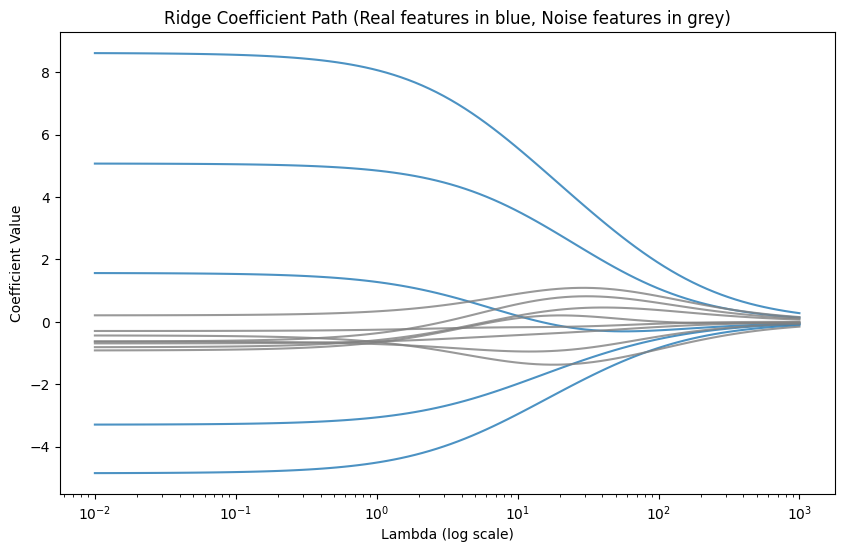

In [15]:
lambdas_path = np.logspace(-2, 3, 100)
coefs_path = np.array([fit_ridge(Z_train, y_train, l)[1:] for l in lambdas_path])

plt.figure(figsize=(10, 6))
for i in range(coefs_path.shape[1]):
    color = 'tab:blue' if i < 5 else 'grey'
    plt.plot(lambdas_path, coefs_path[:, i], color=color, alpha=0.8)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Coefficient Path (Real features in blue, Noise features in grey)')
plt.show()

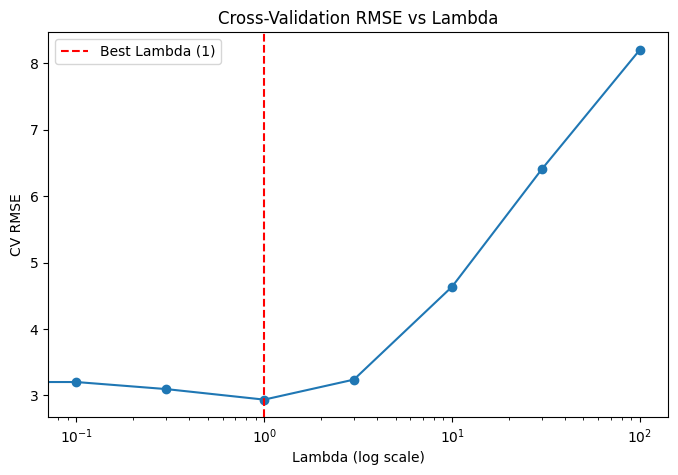

In [16]:
lambdas_cv = [0, 0.1, 0.3, 1, 3, 10, 30, 100]
cv_rmses = [k_fold_cv(X_train, y_train, l, k=5, seed=0) for l in lambdas_cv]

plt.figure(figsize=(8, 5))
plt.plot(lambdas_cv, cv_rmses, marker='o')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('CV RMSE')
plt.title('Cross-Validation RMSE vs Lambda')
plt.axvline(best_lam, color='red', linestyle='--', label=f'Best Lambda ({best_lam})')
plt.legend()
plt.show()

In [17]:
def soft_threshold(v, t):
    return np.sign(v) * np.maximum(np.abs(v) - t, 0)

def fit_lasso(X, y, lam, lr=0.05, n_iters=30000):
    A = design_matrix(X)
    n_samples, n_features = A.shape
    theta = np.zeros(n_features)
    
    for _ in range(n_iters):
        grad = -2 * A.T @ (y - A @ theta) / n_samples
        theta = theta - lr * grad
        t = lr * lam
        theta[1:] = soft_threshold(theta[1:], t)
        
    return theta

lasso_lambdas = [0.1, 0.5, 1.0, 2.0]
for lam in lasso_lambdas:
    theta_l = fit_lasso(Z_train, y_train, lam)
    eliminated = [features[i] for i, val in enumerate(theta_l[1:]) if abs(val) < 1e-8]
    print(f"Lasso Lambda {lam:3.1f} | Exact zeros: {len(eliminated)} | Eliminated: {eliminated}")

theta_r = fit_ridge(Z_train, y_train, best_lam)
theta_l = fit_lasso(Z_train, y_train, 1.0)

comparison_df = pd.DataFrame({
    'Feature': ['intercept'] + features,
    'Ridge': theta_r,
    'Lasso': theta_l
})
print("\nComparison of Ridge and Lasso Coefficients:")
print(comparison_df)

Lasso Lambda 0.1 | Exact zeros: 0 | Eliminated: []
Lasso Lambda 0.5 | Exact zeros: 4 | Eliminated: ['noise_c', 'noise_d', 'noise_tiny2', 'noise_tiny3']
Lasso Lambda 1.0 | Exact zeros: 6 | Eliminated: ['noise_a', 'noise_c', 'noise_d', 'noise_id', 'noise_tiny2', 'noise_tiny3']
Lasso Lambda 2.0 | Exact zeros: 8 | Eliminated: ['floors', 'noise_a', 'noise_c', 'noise_d', 'noise_id', 'noise_tiny1', 'noise_tiny2', 'noise_tiny3']

Comparison of Ridge and Lasso Coefficients:
        Feature      Ridge      Lasso
0     intercept  52.767500  52.767500
1          area   8.073606   7.612767
2         rooms   4.851547   4.195519
3           age  -3.064042  -2.103163
4       dist_km  -4.513723  -3.931242
5        floors   1.278401   0.130740
6       noise_a  -0.659202  -0.000000
7       noise_b  -0.650180  -0.516968
8       noise_c  -0.589405   0.000000
9       noise_d   0.335358   0.000000
10     noise_id  -0.629226  -0.000000
11  noise_tiny1  -0.712694  -0.079443
12  noise_tiny2  -0.253098  -0.00000